# Trade Network Embeddings

We will plot embeddings of the oil trade network (HS 2709)

In [16]:
import numpy as np
import umap
import matplotlib.pyplot as plt

In [26]:
# Pre-processing the embedding file for the k-nearest-neighbours function (returns a dictionary of embeddings)

def load_embeddings(path):
    embeddings = {}
    with open(path, 'r') as f:
        first_line = f.readline().split()
        num_nodes, dim = int(first_line[0]), int(first_line[1])
        for line in f:
            parts = line.split()
            node_id = str(parts[0])
            vec = np.array(parts[1:], dtype=float)
            embeddings[node_id] = vec
    return embeddings


In [25]:
# This function finds the k nearest neighbours to a country (node), given an embedding (path) and a metric

def k_nearest_neighbours(node, k, path, metric):
    embeddings = load_embeddings(path)
    countryid = node

    if countryid not in embeddings:
        raise ValueError(f"Node '{countryid}' not found in embeddings.")

    target_vec = embeddings[countryid]
    node_ids = list(embeddings.keys())

    # preallocate properly instead of distances[i] on an empty list
    distances = np.zeros(len(node_ids))
    for i, other_id in enumerate(node_ids):
        distances[i] = metric(target_vec, embeddings[other_id])

    # exclude the node itself before picking neighbours
    self_idx = node_ids.index(countryid)
    distances[self_idx] = -np.inf  # so it never gets picked as a "nearest" match by cos_sim

    nearest_idx = np.argpartition(-distances, k)[:k]  # top-k by similarity
    nearest_idx = nearest_idx[np.argsort(-distances[nearest_idx])]  # sort by similarity desc

    # return [(node_ids[i], distances[i]) for i in nearest_idx]
    return [str(node_ids[i])for i in nearest_idx]

# Functions for measuring similarity between nodes in an embedding

def cos_sim(a,b):
    # computes the cosine similarity between 2 vectors
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euc_dist(a,b):
    # computes the euclidean distance between 2 vectors
    return np.linalg.norm(a - b)


In [19]:
# Pre-processing the embedding file for the UMAP plot function (returns an array of embeddings and a list of nodes)

def load_embedding_file(path, dtype=np.float32):

    node_ids = []
    vectors = []

    with open(path, "r") as f:
        first_line = f.readline().strip()
        n_nodes, dim = map(int, first_line.split())

        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            node_id = parts[0]
            vec = np.array(parts[1:], dtype=dtype)

            if vec.shape[0] != dim:
                raise ValueError(f"Dimension mismatch for node {node_id}")

            node_ids.append(node_id)
            vectors.append(vec)

    X = np.vstack(vectors)
    return X, node_ids


In [37]:
# This function takes an embedding (created by node2vec) and displays a UMAP plot

def plot_umap(
    embedding,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    title="UMAP projection",
    annotate=True,
):
    
    X, node_ids = load_embedding_file(embedding)
    labels = node_ids

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state = 42 # fix a random seed for reproducibility
    )

    X_2d = reducer.fit_transform(X)
    
    plt.figure(figsize=(9, 7))
    plt.title(title)
    plt.scatter(X_2d[:, 0], X_2d[:, 1], s=25, edgecolors="k", linewidths=0.3)
    texts = []
    for i, node in enumerate(labels):
            texts.append(
                plt.annotate(str(node), (X_2d[i, 0], X_2d[i, 1]), fontsize=7)
            )
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()

    plt.show()

    return 

# Plots

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


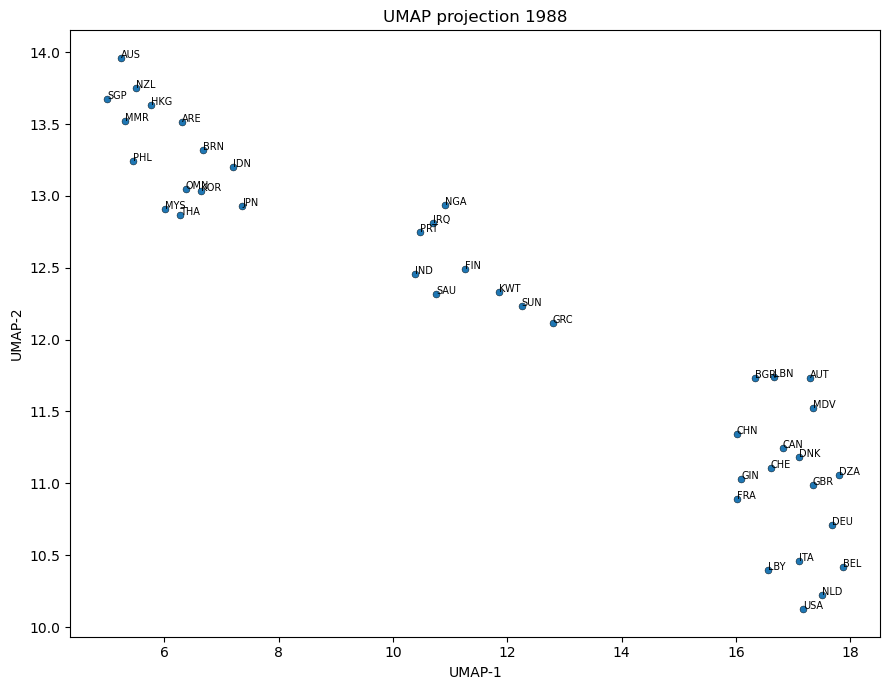

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


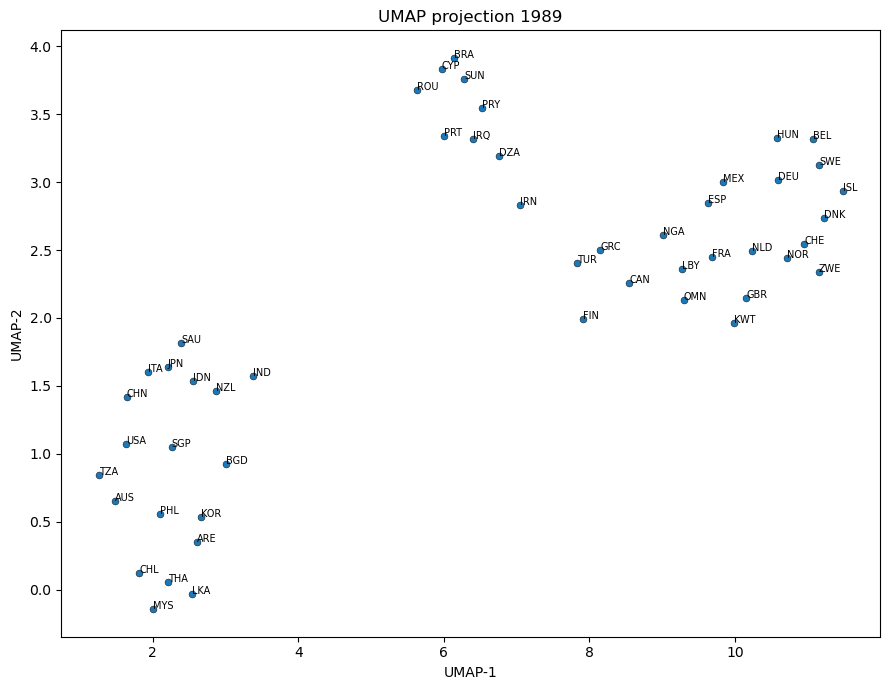

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


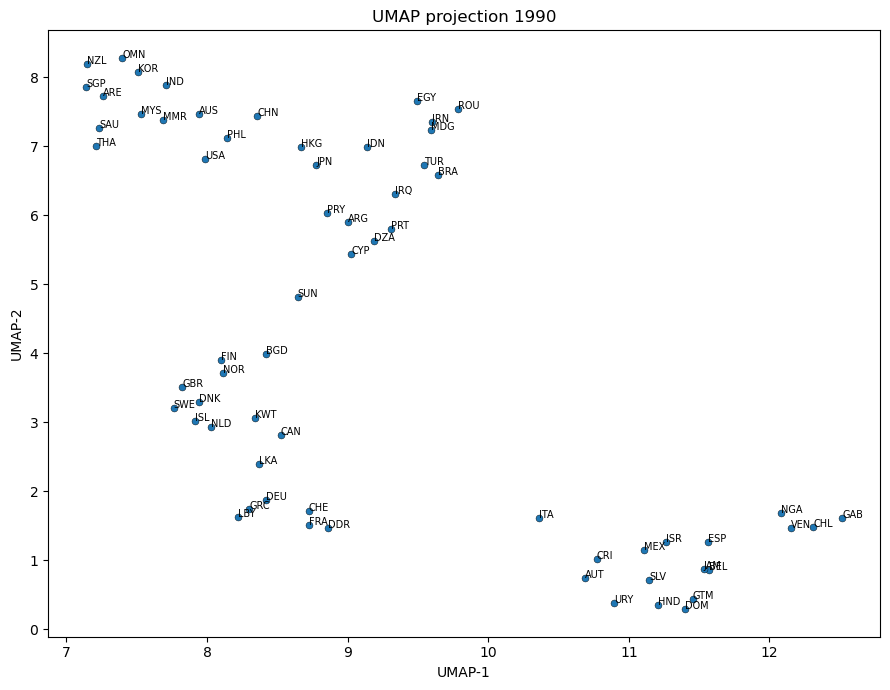

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


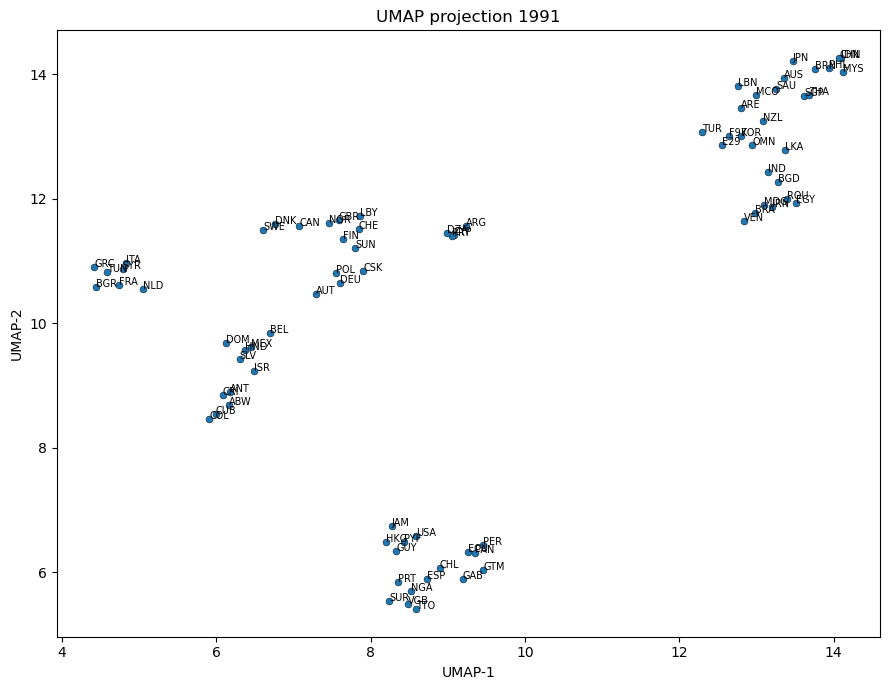

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


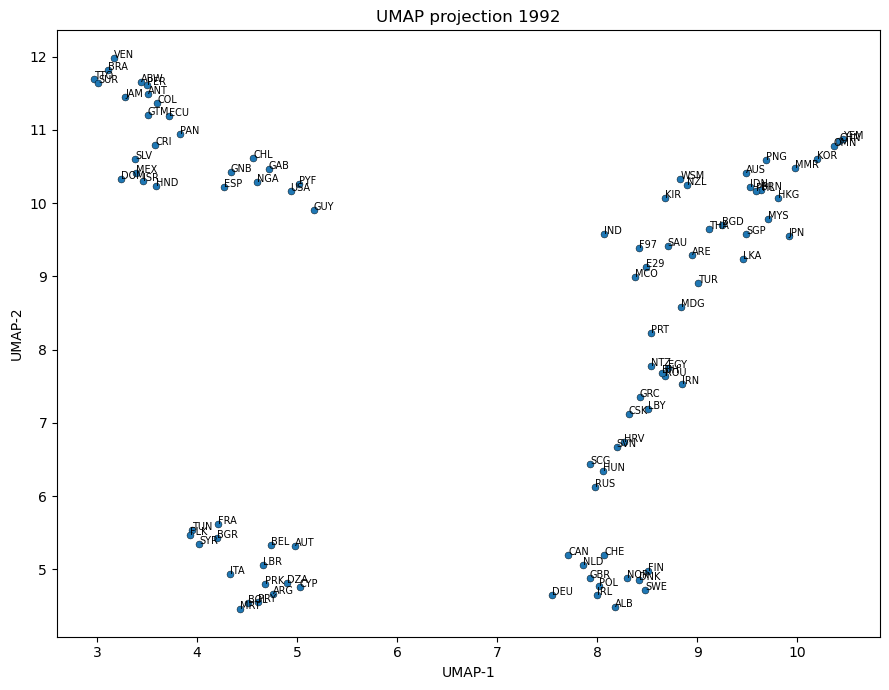

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


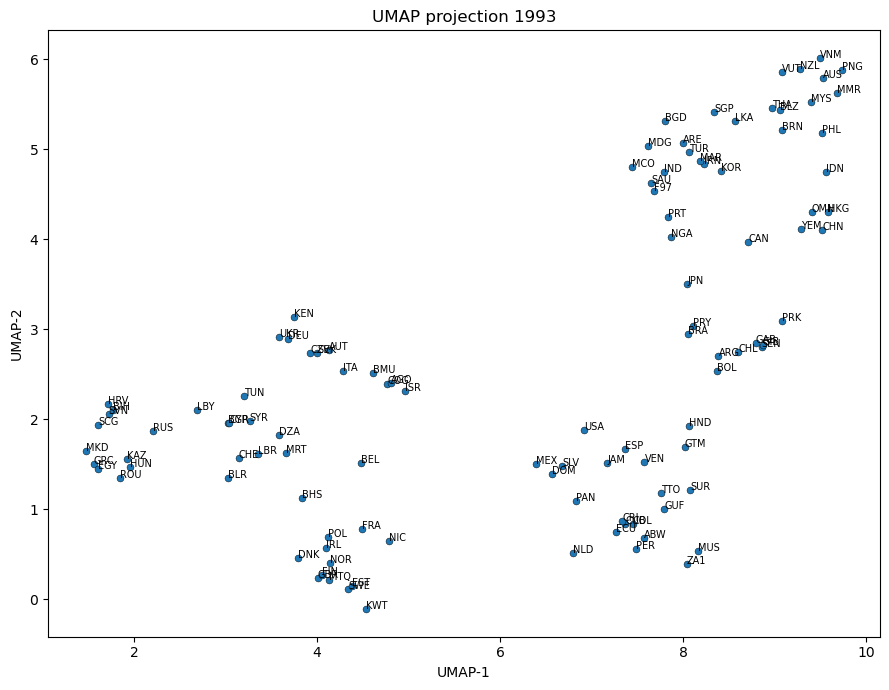

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


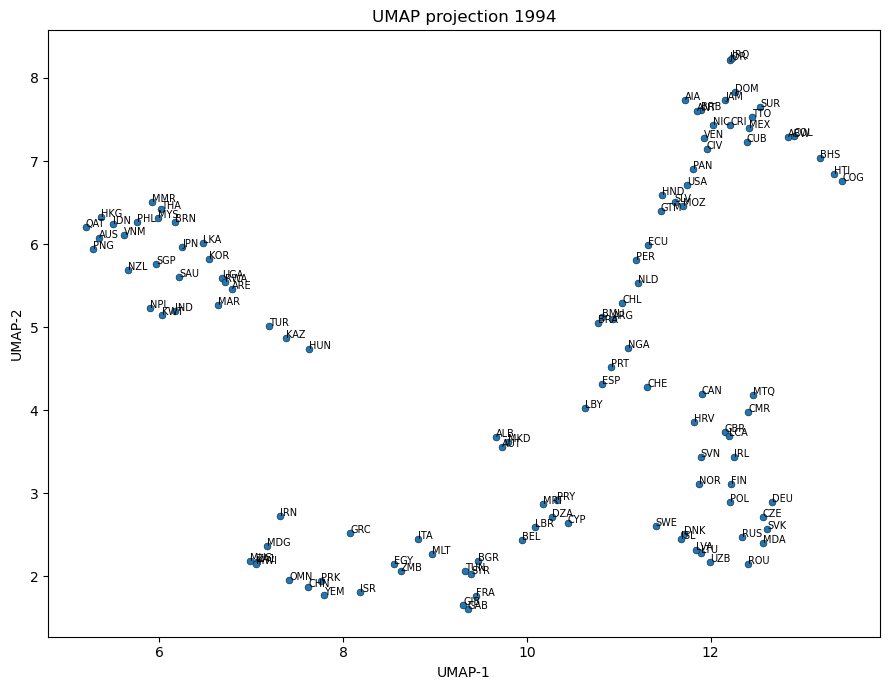

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


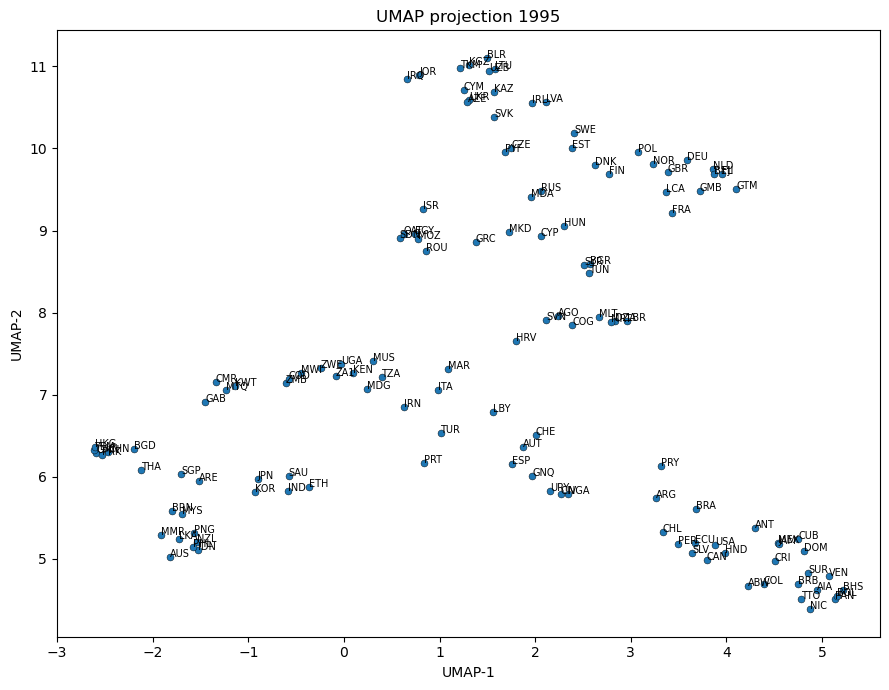

In [39]:
plot_umap("embeddings/oil_k3_1988.emb", title="UMAP projection 1988")
plot_umap("embeddings/oil_k3_1989.emb", title="UMAP projection 1989")
plot_umap("embeddings/oil_k3_1990.emb", title="UMAP projection 1990")
plot_umap("embeddings/oil_k3_1991.emb", title="UMAP projection 1991")
plot_umap("embeddings/oil_k3_1992.emb", title="UMAP projection 1992")
plot_umap("embeddings/oil_k3_1993.emb", title="UMAP projection 1993")
plot_umap("embeddings/oil_k3_1994.emb", title="UMAP projection 1994")
plot_umap("embeddings/oil_k3_1995.emb", title="UMAP projection 1995")

In [23]:
k_nearest_neighbours('CAN', 10, "embeddings/oil_k3_2021.emb", cos_sim)

['SPM', 'MNG', 'DJI', 'IRL', 'HKG', 'TGO', 'GIB', 'NGA', 'PAK', 'VNM']

In [24]:
k_nearest_neighbours('RUS', 10, "embeddings/oil_k3_2021.emb", cos_sim)

['FIN', 'SVK', 'HUN', 'MRT', 'UZB', 'ALB', 'BLR', 'TUR', 'KAZ', 'HRV']